####[실습] 유방암데이터 분류분석

In [86]:
# 데이터 추출 및 분할 (train 0.8*0.3, validataion 0.8*0.3, test = 0.2)
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,  stratify=cancer.target, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, stratify=y_train,  random_state=42)

In [50]:
# 모델 설계 (input > 32(ReLU) > 16(ReLU) > output(?))
from tensorflow.keras import models, layers

model = models.Sequential([
    # X_train.shape[1] → 특성(feature) 개수
    # 입력층에서는 몇 개의 숫자가 들어오는지를 명확히 지정해야한다.
    layers.InputLayer(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')

])

In [10]:
# 학습 준비 (optimizer = adam, loss = 문제에 맞추어 지정)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [11]:
# 모델 학습 (100번 반복)
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5205 - loss: 25.8613
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4660 - loss: 5.3194  
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5548 - loss: 2.1571 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8207 - loss: 0.7274 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8839 - loss: 0.3858
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9077 - loss: 0.2713
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8995 - loss: 0.3140 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9090 - loss: 0.2593 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8947 - loss: 0.2582 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9118 - loss: 0.2519 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9343 - loss: 0.1867 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

In [12]:
# 모델 평가
model.evaluate(X_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8846 - loss: 0.2752  


[0.2665327191352844, 0.8859649300575256]

In [22]:
# test의 10번째 값의 예측값과 실제값 동일여부 확인

# 예측
predictions = model.predict(X_test)
predicted_labels = (predictions >= 0.5).astype(int)  # 0.5 이상은 1, 미만은 0으로 변환

# 동일여부
print("예측값: ",predicted_labels[9][0],", 실제값: ",y_test[9])
if predicted_labels[9][0] == y_test[9]:
  print("예측값과 실제값이 동일합니다.")
else :
  print("예측값고 실제값이 다릅니다.")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
예측값:  0 , 실제값:  0
예측값과 실제값이 동일합니다.


##### 풀이

In [87]:
from tensorflow.keras import layers, models

model = models.Sequential([  # 변수명을 'models'에서 'model'로 수정
    layers.InputLayer(shape=(X_train.shape[1],)),  # 입력층
    layers.Dense(32, activation='relu'),  # 첫 번째 은닉층
    layers.Dense(16, activation='relu'),  # 두 번째 은닉층
    layers.Dense(1, activation='sigmoid')  # 출력층: 이진 분류이므로 sigmoid 활성화 함수
])


In [88]:
# 학습 준비
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 이진분류모델이므로 binary_crossentropy

In [89]:
# 모델 학습
# 방법 2가지
model.fit(X_train, y_train, epochs=100, validation_data=(X_val,y_val))
# 위에서 안나누고 여기서 할 수 있다.
# model.fit(X_train, y_train, epochs=100, validation_split=0.3)

# 결과에서 10/10이 나타나는 것은 자동으로 배치사이즈를 32로 가져간다
# 전체 데이터 크기를 32로 나눠서 그 분할이 10개가 생겼다고 볼 수 있다.

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.8089 - loss: 2.1220 - val_accuracy: 0.8175 - val_loss: 1.9319
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8794 - loss: 1.2364 - val_accuracy: 0.7518 - val_loss: 1.6076
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8267 - loss: 0.8406 - val_accuracy: 0.8540 - val_loss: 1.2655
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8683 - loss: 0.8354 - val_accuracy: 0.8175 - val_loss: 0.9930
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8972 - loss: 0.8195 - val_accuracy: 0.8248 - val_loss: 0.9114
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8520 - loss: 0.6551 - val_accuracy: 0.8759 - val_loss: 0.8843
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8887 - loss: 0.6080 - val_accuracy: 0.8832 - val_loss: 0.7181
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9158 - loss: 0.3707 - val_accuracy: 0.

In [90]:
X_test.shape # -> 114/32 = 하나 올림해서 4개가 나온다.

(114, 30)

In [91]:
# 모델 평가
model.evaluate(X_test,y_test)

#  accuracy: 0.9295 - loss: 0.1736
# [0.1887667030096054, 0.9122806787490845]
# 값이 다른 이유 : 위에꺼는 4개의 배치 돈것에 대한 평균
# 밑에는 전체 데이터에 대한 계산 (이쪽이 더 정확함)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9295 - loss: 0.1736


[0.1887667030096054, 0.9122806787490845]

In [94]:
# 값 비교
import tensorflow as tf
sample = X_test[10, :].reshape(1,-1)
sample_pred = tf.round(model.predict(sample),0) # 확률값이 나오므로 round 사용

if sample_pred == y_test[10]:
  print("정답")
else:
  print("오답")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
정답


#### [실습] 당뇨병 수치 예측

In [96]:
# 데이터 추출 및 분할 (train 0.8*0.3, validataion 0.8*0.3, test = 0.2)
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

X_train, X_test, y_train, y_test = train_test_split(diabetes.data,
                                                    diabetes.target,
                                                    test_size=0.2,
                                                    random_state=42)

In [43]:
# 모델 설계 (input > 64(ReLU) > 32(ReLU) > 16(ReLU) > output(?))
model = models.Sequential([
    layers.InputLayer(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
    # 당뇨병 수치예측은 회귀문제(연속적인 값)이므로 출력층에서 활성화함수 사용하지 않고
    # 선형 활성화함수 즉 기본값사용
])

In [44]:
# 학습 준비 (optimizer = SGD, loss = 문제에 맞추어 지정)
model.compile(optimizer = 'SGD', loss = 'mean_squared_error', metrics=['mean_squared_error'])

In [45]:
# 모델 학습 (100번 반복, batch_size = 64)
model.fit(X_train, y_train, epochs = 100,batch_size = 64,validation_split=0.3)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 23890.6953 - mean_squared_error: 23890.6953 - val_loss: 244404448.0000 - val_mean_squared_error: 244404448.0000
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 495501728.0000 - mean_squared_error: 495501728.0000 - val_loss: 79673.1719 - val_mean_squared_error: 79673.1719
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 85424.2266 - mean_squared_error: 85424.2266 - val_loss: 68229.3125 - val_mean_squared_error: 68229.3047
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 74607.5156 - mean_squared_error: 74607.5156 - val_loss: 58554.9570 - val_mean_squared_error: 58554.9531
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 60657.5508 - mean_squared_error: 60657.5508 - val_loss: 50337.4336 - val_mean_squared_error: 50337.4336
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 53097.2383 - mean_squared_error: 53097.2383 - val_loss: 43369.6133 - val_mean_squared_error: 43369.6133
Epoch 7/100


In [46]:
# 모델 평가
model.evaluate(X_test,y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5782.5239 - mean_squared_error: 5782.5239


[5317.15771484375, 5317.15771484375]

In [49]:
# test의 10번째 값의 예측값과 실제값 동일여부 확인
predictions = model.predict(X_test)

print("예측값:",predictions[9][0], "실제값:",y_test[9])
if predictions[9][0] == y_test[9]:
  print("예측값과 실제값이 동일합니다.")
else :
  print("예측값과 실제값이 다릅니다.")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
예측값: 150.13484 실제값: 96.0
예측값과 실제값이 다릅니다.


##### 풀이

In [98]:
# 모델 설계 (input > 64(ReLU) > 32(ReLU) > 16(ReLU) > output(?))
model = models.Sequential([
    layers.InputLayer(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

In [99]:
# 학습 준비
import tensorflow as tf
#from sklearn.metrics import r2_score

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001) # sgd는 learning_rate기본값이 0.01로 급격하게 loss가 떨어지는 것을 막기 위해 0.001로 설정하였다.
model.compile(optimizer='adam', loss='mae', metrics=['r2_score'])

In [100]:
# 모델 학습
model.fit(X_train,y_train, epochs=100, batch_size=64, validation_split=0.3)
# r2_score가 - 이기 때문에 학습을 잘 못한 모델이라고 볼 수 있다 (model이나 optimizer를 변경)
# 그렇게 때문에 다시 옵티마이저를 sqd가 아닌 adam으로 바꿔주었다.

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 160.0051 - r2_score: -4.2853 - val_loss: 141.6204 - val_r2_score: -3.4860
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 160.4184 - r2_score: -4.1233 - val_loss: 141.5800 - val_r2_score: -3.4840
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 163.9188 - r2_score: -4.0669 - val_loss: 141.5348 - val_r2_score: -3.4817
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 160.3484 - r2_score: -4.2418 - val_loss: 141.4826 - val_r2_score: -3.4791
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 159.1397 - r2_score: -4.1585 - val_loss: 141.4221 - val_r2_score: -3.4761
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 164.7992 - r2_score: -4.4785 - val_loss: 141.3503 - val_r2_score: -3.4725
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 159.8007 - r2_score: -4.0276 - val_loss: 141.2649 - val_r2_score: -3.4682
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 159.0099 - r2_sco

In [101]:
model.evaluate(X_test,y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 46.3614 - r2_score: 0.4325


[45.216041564941406, 0.4208790063858032]

In [84]:
sample = X_test[10,:].reshape(1,-1)
sample_pred=model.predict(sample)

# 정확히 동일한 값이 나오지는 않는다.
print(sample_pred, y_test[10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
[[92.84021]] 94.0


# 과대적합
- 과대적합(overfitting)은 모델이 학습데이터의 노이즈나 세부적인 패턴을 지나치게 학습하여 새로운 데이터에 대한
일반화 성능이 떨어지는 현상
    - 학습 데이터에서는 높은 정확도를 보이지만, 평가 데이터나 학습하지 않은 데이터에 대해선 성능이 저하
- 과대적합의 주요 원인은 다음과 같음
    - 신경망의 계층 수가 많고 각 계층의 뉴런 수가 많은 복잡한 모델은 더 많은 매개변수를 가지며, 이로 인해 학습 데이터의 세부적인 패턴까지 학습할 수 있게 됨
    - 데이터가 충분하지 않으면 모델이 학습할 데이터가 적어 학습 데이터에만 특화된 학습을 수행함

## 과대적합 방지 방법
- 학습 데이터를 더 많이 수집하면 모델이 더 일반적인 패턴을 학습하게 되어 과대적합이 줄어들 수 있음
- 정칙화(Regularization) : L1/L2 정칙화를 통해 손실함수에 가중치의 크기를 페널티로 추가하여 모델이 너무 복잡해지는 것을 방지함
- 드랍아웃(Dropout) : 학습 중에 신경망의 일부 뉴런을 무작위로 꺼서 신경망이 특정 뉴런이나 경로에 과도하게 의존하는 것을 방지함
- 얼리스탑핑(Early Stopping) : 과대적합이 시작되기 전(검증 데이터의 성능이 더 이상 개선되지 않을 때)에 학습을 중지
- 배치정규화(Batch Normalization) : 여러 모델을 결합하여 예측하여 개별 모델의 편향된 학습을 줄이고 일반화 성능을 향상

### 정칙화(Regularization)
- 정칙화는 모델의 가중치를 규제(Regularization)하여 과적합을 방지하는 기법으로 손실 함수에 페널티(penalty)를 추가하여 모델이 학습 데이터에 대한 손실만 보고 학습되는 것을 방지함
- L2 정칙화 (Weight Decay)
    - 가중치의 제곱의 합을 손실 함수에 더하는 방식으로 특정 가중치에 영향력이 집중되는 것을 방지하고 모든 가중치들이 최소한의 영향력을 유지시킬 수 있도록 조정함
    - 모든 가중치를 작게 만드는 경향이 있어 모델이 더 매끄럽고 일반화되는 데 도움을 줌
    - 딥러닝에서 기본적으로 사용하는 정칙화 기법이며, 옵티마이저(optimizer)에서 weight_decay파라미터로 적용 가능
    ```
tf.keras.optimizers.<옵티마이저명>(weight_decay)
```
- L1 정칙화
    - 가중치 절대값의 합을 손실 함수에 더하는 방식으로 주요한 특성에 대해서 집중할 수 있도록 조정함
    - 데이터가 복잡하고 고차원 모델인 경우 중요한 특성만 집중하는 것이 효과적일 수 있으나, 중요한 특성도 제외될 위험이 있음
    - Dense Layer에서 `kernel_regularizer`인자를 통해 적용 가능하며, `regularizers`모듈을 이용하여 지정
    ```
tf.keras.layers.Dense(kernel_regularizer=None)
```
    - L1 : regularizers.L1(l1 = 0.01), 'l1'
    - L2 : regularizers.L2(l2 = 0.01), 'l2'
    - L1, L2 동시 적용 : regularizers.L1_L2(l1=0.0, l2=0.0), 'l1_l2'



In [ ]:
# L1 은 가중치를 0으로 변하면서 많은 변수들을 제외해 안정성이 떨어질 수 있어 딥러닝에서는 L2를 더 많이 쓴다.

### 드랍아웃(Dropout)
- 드롭아웃은 학습 과정에서 무작위로 일부 뉴런을 일시적으로 제거하는 방식으로 작동
    - 모델이 특정 뉴런이나 뉴런의 조합에 과도하게 의존하지 않도록 하여 더 일반화된 모델을 학습
- 드롭아웃은 일반적으로 신경망의 은닉층에 적용하며 드롭아웃을 적용할 레이어를 선택하고, 드롭아웃 비율을 설정함
    - 드롭아웃 비율이 0.5라면, 해당 레이어의 뉴런 중 50%가 학습 단계에서 무작위로 제거
- 학습이 진행되는 동안 각 배치마다 지정된 드롭아웃 비율에 따라 무작위로 뉴런을 비활성화하며 비활성화된 뉴런은 해당 학습 단계에서 출력에 기여하지 않음
- 평가(또는 예측) 단계에서는 드롭아웃을 사용하지 않으며 모든 뉴런을 활성화하고, 학습동안 비활성화된 뉴런에 대한 보상을 하기 위해 각 뉴런의 출력을 드롭아웃 비율만큼 스케일 조정
- Dropout 레이어를 추가
```
tf.keras.layers.Dropout(rate, seed=None)
```
    - `rate` : 드랍아웃 비율 설정 (0.2~0.5)
    - `seed` : 랜덤하게 뉴런을 제거할 때 seed를 고정하는 값
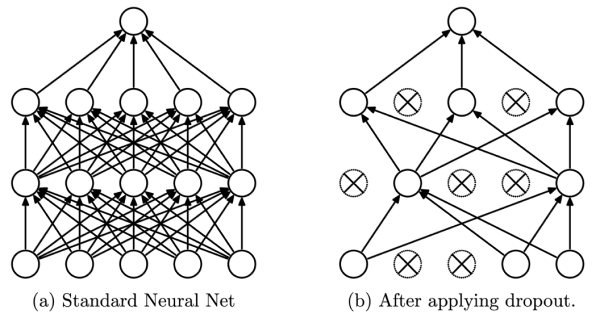

### 얼리스탑핑(Early Stopping)
- 너무 많은 에포크로 인한 과적합을 방지하기 위한 방법
- 학습 중 검증 데이터(validation data)의 성능이 개선되지 않으면 학습을 중지하는 방식으로 과적합이 발생하는 시점을 판단하고, 그 전에 학습을 종료하여 모델의 일반화 성능을 높임
- 학습 데이터를 훈련(train) 데이터와 검증(validation) 데이터로 나누어 훈련 데이터는 모델의 가중치를 업데이트하는 데 사용되고,검증 데이터는 학습 중간중간 모델이 새로운 데이터에 대해 얼마나 잘 일반화되고 있는지를 평가하는 데 사용
- 각 에폭(epoch)마다 검증 데이터에서의 성능(예: 손실 또는 정확도)을 모니터링하며 검증 성능이 개선되지 않고 일정 에폭 이상 멈추면 학습을 중지하며 검증 성능이 가장 좋았던 시점의 모델을 저장해두고, 이후 학습을 중지한 후 저장된 모델을 사용
```
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=0, restore_best_weights=False)
model.fit(callback=[early_stop])
```
    - `monitor` : 모니터링할 값
    - `patience` : 개선되지 않는 epoch수
    - `restore_best_weights` : 최상의 가중치를 복원

In [ ]:
# monitor='loss' : 그냥 데이터로 하는 경우 설정

### 배치 정규화(Batch Normalization)
- 배치 정규화(Batch Normalization, BatchNorm)는 딥러닝 모델의 훈련을 안정화하고 가속화하기 위해 사용되는 기법
- 각 미니배치(mini-batch) 내에서 신경망의 출력 값을 정규화하여, 신경망의 각 층이 적절한 분포의 입력을 받을 수 있도록 함
    - 기울기 소실(vanishing gradient) 문제를 완화하고, 학습 속도를 향상시키며, 네트워크의 일반화 성능을 개선
- 딥러닝 모델에서 각 레이어의 입력 분포는 학습 과정 동안 변화할 수 있으며 내부 공변량 변화(Internal Covariate Shift)라고 함
    - 내부 공변량 변화가 심할수록 학습이 불안정해지고 느려질 수 있음
- 배치 정규화는 각 층의 입력 분포가 변경되지 않도록 정규화해서 이러한 문제를 해결
    - 배치 정규화는 네트워크의 각 층에서 배치의 평균과 분산을 사용하여 출력 값을 정규화 후 활성화 함수에 전달
    - 정규화된 값에 대해 학습 가능한 파라미터인 gamma(scale factor)와 beta(shift factor)를 곱하고 더하는 방식으로 출력을 조정 <br>
$y_i = \gamma \hat{x_i} + β$ <br>
        - 출력값에 대하여 정규화 <br>
$\hat{x_i} = \frac{x_i - \mu B}{σ_B + ϵ}$
        - 각 미니배치별 평균과 분산 계산 <br>
$\mu B = \frac{1}{m}\sum_{i=1}^m x_i$ <br>
$σ_B^2 = \frac{1}{m}\sum_{i=1}^m(x_i - \mu B)^2$
- 배치 정규화의 장점
    - 각 레이어가 안정된 분포의 입력을 받도록 하여 학습률을 더 크게 설정해 학습 과정을 빠르게 진행하고수렴 가속화
    - 배치 정규화를 사용하면 네트워크가 초기 가중치에 덜 민감하게 되며 복잡한 네트워크에서 특히 유리함
    - 출력값이 표준화된 분포를 가지도록 함으로써 기울기 소실문제를 완화하고 더 깊은 신경망에서도 학습이 원활하게 이루어질 수 있도록 함
    - 훈련 시 랜덤하게 나누어진 미니배치의 통계적 변화를 사용하기 때문에, 드롭아웃과 유사한 정규화 효과를 가질 수 있으며 이는 모델의 과대적합을 방지하는 데 도움
- 배치 정규화의 단점
    - 작은 미니배치 크기를 사용할 경우 배치 정규화의 평균과 분산 추정이 정확하지 않을 수 있으며 는 특히 미니배치 크기를 작게 설정해야 하는 상황에서 문제가 될 수 있음
    - RNN과 같은 순차 모델에서는 배치 정규화를 적용하기 어려우며 이는 시퀀스 데이터의 특성상 미니배치 내의 데이터가 독립적이지 않아 Layer Normalization 또는 다른 변형 기법들을 사용함
    - 배치 정규화를 사용하는 경우, 훈련과 추론 단계에서의 동작이 다르기 때문에 추가적인 계산 비용이 발생할 수 있으며 추론 단계에서는 각 계층별 평균과 분산을 미리 계산하여 사용해야 함
- BatchNormalization 레이어 사용
```
tf.keras.layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)
```
    - `axis` : 정규화할 차원 (특성의 차원을 지정)
    - `momentum` : 이동 평균 계수(추론 시 평균과 분산을 추적할 때 사용)
    - `epsilon` : 매우 작은 상수값 (분모가 0이 되는 것을 방지)

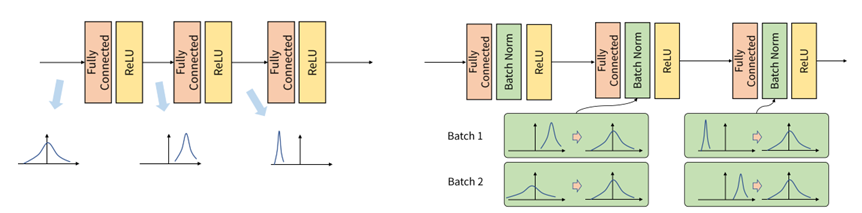


#### [예제] digit 이미지 데이터 분류

In [102]:
from tensorflow import keras
import tensorflow as tf

In [103]:
# 데이터 추출 및 분할
from sklearn.datasets import load_digits
digits = load_digits()

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, stratify= digits.target, test_size=0.2)

In [129]:
# 모델 설계
from keras import *

model = models.Sequential([
    layers.InputLayer(shape=(X_train.shape[1],)),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax') # 0부터 9까지 숫자이므로 10
])

In [135]:
# 학습 준비
optimizer = keras.optimizers.RMSprop(weight_decay=0.01) # L2 정칙화
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# optimizer=optimizer 로도 써보고 optimizer='rmsprop'로도 써봄
# sparse_categorical_crossentropy 우리의 결과데이터를#

In [136]:
# 모델 학습
es = tf.keras.callbacks.EarlyStopping(patience=3)
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.3, verbose=0, callbacks=[es]) # verbose=0를 제거해 진행상황을 볼 수 있다.

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9784 - loss: 0.1002 - val_accuracy: 0.9491 - val_loss: 0.1422
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9764 - loss: 0.0879 - val_accuracy: 0.9537 - val_loss: 0.1342
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9855 - loss: 0.0674 - val_accuracy: 0.9537 - val_loss: 0.1276
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9851 - loss: 0.0657 - val_accuracy: 0.9745 - val_loss: 0.1126
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9852 - loss: 0.0704 - val_accuracy: 0.9745 - val_loss: 0.0827
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9886 - loss: 0.0501 - val_accuracy: 0.9769 - val_loss: 0.0913
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9930 - loss: 0.0403 - val_accuracy: 0.9630 - val_loss: 0.1167
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9920 - loss: 0.0495 - val_accuracy: 0.9699 - val

In [137]:
# 모델 평가
model.evaluate(X_test, y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9880 - loss: 0.0498 


[0.04887416586279869, 0.9888888597488403]

In [138]:
# 예측값 확인
y_prob = model.predict(X_test)
y_pred = y_prob.argmax(axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


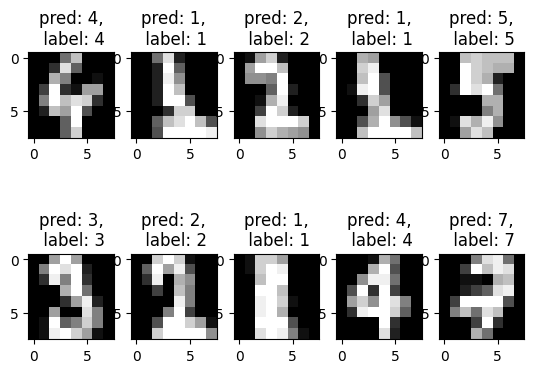

In [139]:
# 시각화
import matplotlib.pyplot as plt

for i in range(10):
    plt.subplot(2,5, i+1)
    plt.imshow(X_test[i].reshape(8,8), cmap='gray')
    plt.title(f'pred: {y_pred[i]},\n label: {y_test[i]}')

#[실습] 당뇨병 수치 예측에 대해 정확도를 향상시켜보자.
- 레이어, 활성화함수, 옵티마이저 설정 (자유)
- 다양한 과대적합 방지방법 적용 (자유)
- 평가데이터에 대한 정확도를 향상시킬 수 있는 방법 확인

In [174]:
from tensorflow import keras
import tensorflow as tf

In [307]:
# 데이터 추출 및 분할
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=42)

In [180]:
# from sklearn.preprocessing import *
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(diabetes.data)
# poly = PolynomialFeatures(degree=3, include_bias=False)
# X_poly = poly.fit_transform(X_scaled)

# X_train, X_test, y_train, y_test = train_test_split(X_poly, diabetes.target, test_size=0.2)

In [429]:
# 모델 설계
from keras import *

model = models.Sequential([
    layers.InputLayer(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

In [441]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, weight_decay=0.01)
model.compile(optimizer=optimizer, loss='mse', metrics=['r2_score'])

In [442]:
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.fit(X_train, y_train, epochs=1000, batch_size=16, validation_split=0.3, callbacks=[es])

Epoch 1/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 2959.2251 - r2_score: 0.5398 - val_loss: 3357.4519 - val_r2_score: 0.4164
Epoch 2/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2794.7026 - r2_score: 0.5126 - val_loss: 3828.7083 - val_r2_score: 0.3345
Epoch 3/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3245.9746 - r2_score: 0.4333 - val_loss: 3329.3755 - val_r2_score: 0.4213
Epoch 4/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2906.4104 - r2_score: 0.4909 - val_loss: 3339.5596 - val_r2_score: 0.4195
Epoch 5/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3217.0913 - r2_score: 0.4701 - val_loss: 3431.3254 - val_r2_score: 0.4036
Epoch 6/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2769.4956 - r2_score: 0.5279 - val_loss: 3460.5771 - val_r2_score: 0.3985
Epoch 7/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2819.9355 - r2_score: 0.5082 - val_loss: 3333.6721 - val_r2_score: 0.4205
Epoch 8/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - lo

In [443]:
model.evaluate(X_test,y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3168.1460 - r2_score: 0.4415


[2995.6201171875, 0.43459147214889526]

In [445]:
model.summary()

Model: "sequential_72"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_236 (Dense)                    │ (None, 128)                 │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_58               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_58 (ReLU)                      │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_90 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_237 (Dense)                    │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_91 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_238 (Dense)                    │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_239 (Dense)                    │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,357 (142.02 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 24,068 (94.02 KB)

In [447]:
hidden1=model.layers[0]
weights,biases = hidden1.get_weights()
weights.shape

(10, 128)